### Background and Prior Work

#### Background
Motor-vehicle collisions represent a significant public health challenge in urban environments, contributing to thousands of injuries and fatalities annually. In Seattle, the Seattle Department of Transportation (SDOT) maintains comprehensive records of collision incidents, including spatial coordinates, severity metrics (e.g., fatalities and injuries), and temporal details. Understanding the spatial distribution of these collisions is crucial for urban planning, as it allows for targeted safety interventions such as improved signage, traffic calming measures, or infrastructure upgrades in high-risk areas.

In recent years, SDOT has introduced several policies to mitigate collision risks, building on broader initiatives like the Vision Zero program adopted in 2015. Vision Zero aims to eliminate traffic deaths and serious injuries by 2030 through a combination of engineering improvements, education, and enforcement. Key measures include prohibiting right turns on red lights at select high-risk intersections to protect pedestrians and cyclists, expanding protected bike lanes, and implementing pedestrian-priority designs in downtown and residential areas. These policies may have influenced collision patterns, particularly in urban cores, by altering driver behavior and reducing exposure at vulnerable points.

The COVID-19 pandemic introduced unprecedented disruptions to daily mobility patterns. Lockdowns, remote work shifts, and reduced commuting led to lower overall traffic volumes, particularly in city centers. However, anecdotal reports and preliminary studies suggest that while collision frequencies may have decreased, the severity of incidents could have shifted due to changes in driver behavior, such as increased speeding on less congested roads or altered travel patterns favoring highways over local streets. This project examines whether these changes persisted into the post-2020 period and whether spatial hotspots for collisions also correspond to disproportionate shares of severe outcomes.

#### Prior Work
Spatial analysis of traffic collisions has been extensively studied using Geographic Information Systems (GIS) and statistical methods. Research by Erdogan et al. (2008) demonstrated the use of kernel density estimation to identify collision hotspots in urban areas, revealing that a small percentage of road segments account for a large proportion of incidents. Similarly, studies in cities like Los Angeles and New York have employed spatial clustering techniques (e.g., Getis-Ord Gi* statistic) to pinpoint high-risk zones, often linked to factors such as intersection density and traffic volume (Aguero-Valverde & Jovanis, 2006).

Regarding collision severity, prior work highlights that while collision frequency is influenced by exposure (e.g., vehicle miles traveled), severity depends on factors like speed, vehicle type, and environmental conditions. For instance, analyses of the Fatality Analysis Reporting System (FARS) data show that fatalities are more likely in rural or high-speed areas, but urban settings exhibit higher injury rates due to pedestrian involvement (NHTSA, 2022). Vehicle type also plays a role, with larger vehicles (e.g., trucks) associated with higher fatality risks in multi-vehicle crashes (Blower & Green, 2010).

Post-COVID research on traffic safety is emerging. Studies in the UK and US indicate a decline in overall collisions during 2020-2021, attributed to reduced travel, but some regions reported increased severity due to riskier driving behaviors (e.g., higher speeds on empty roads) (Transport for London, 2021; NHTSA, 2021). Spatial shifts have been noted, with fewer incidents in downtown areas but potential increases on arterial roads. However, few studies have specifically examined long-term spatial patterns in Seattle or the relationship between collision density and severity outcomes in the post-pandemic era.

This project builds on these foundations by integrating temporal, spatial, and severity analyses to address gaps in understanding how COVID-19 altered collision landscapes in Seattle.

### Research question:
Did the spatial distribution and severity of motor‑vehicle collisions in Seattle change after 2020, and are high‑density collision areas more likely to experience fatal or injurious outcomes?

### Hypothesis:
Post‑2020 collisions are less frequent and less severe, but the locations with the greatest crash density continue to account for a disproportionate share of fatalities and injuries.

### Data Source

The collision dataset used in this project was obtained from the **Seattle Open Data Portal**. The City of Seattle provides freely accessible, regularly updated records of traffic collisions, including detailed spatial coordinates and severity information. All analyses in this notebook are based on the "SDOT Collision All Years" dataset unless otherwise noted, and credit for data collection goes to the Seattle Department of Transportation through the open data initiative.

### Import

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datetime as dt

In [2]:
# Courtesy of claude.ai by Anthropic
plt.rcParams.update({
    'figure.facecolor': '#ffffff',
    'axes.facecolor':   '#ffffff',
    'grid.color':       '#e5e7eb',
    'text.color':       '#111827',
    'axes.labelcolor':  '#111827',
    'xtick.color':      '#6b7280',
    'ytick.color':      '#6b7280',
})


In [3]:
df = gpd.read_file('data/SDOT_Collision_All_Years.geojson')

In [4]:
df.columns

Index(['OBJECTID', 'SE_ANNO_CAD_DATA', 'INCKEY', 'COLDETKEY', 'REPORTNO',
       'STATUS', 'ADDRTYPE', 'INTKEY', 'LOCATION', 'EXCEPTRSNCODE',
       'EXCEPTRSNDESC', 'SEVERITYCODE', 'SEVERITYDESC', 'COLLISIONTYPE',
       'PERSONCOUNT', 'PEDCOUNT', 'PEDCYLCOUNT', 'VEHCOUNT', 'INJURIES',
       'SERIOUSINJURIES', 'FATALITIES', 'INCDATE', 'INCDTTM', 'JUNCTIONTYPE',
       'SDOT_COLCODE', 'SDOT_COLDESC', 'INATTENTIONIND', 'UNDERINFL',
       'WEATHER', 'ROADCOND', 'LIGHTCOND', 'DIAGRAMLINK', 'REPORTLINK',
       'PEDROWNOTGRNT', 'SDOTCOLNUM', 'SPEEDING', 'ST_COLCODE', 'ST_COLDESC',
       'SEGLANEKEY', 'CROSSWALKKEY', 'HITPARKEDCAR', 'SPDCASENO', 'SOURCE',
       'SOURCEDESC', 'ADDDTTM', 'MODDTTM', 'SHAREDMICROMOBILITYCD',
       'SHAREDMICROMOBILITYDESC', 'geometry'],
      dtype='object')

In [5]:
df.describe()

,OBJECTID,INCKEY,COLDETKEY,INTKEY,PERSONCOUNT,PEDCOUNT,PEDCYLCOUNT,VEHCOUNT,INJURIES,SERIOUSINJURIES,FATALITIES,SEGLANEKEY,CROSSWALKKEY
count,2.588620e+05,258862.000000,258862.000000,86948.000000,258862.000000,258862.000000,258862.000000,258862.000000,258862.00000,258862.000000,258862.000000,258862.000000,2.588620e+05
mean,8.699201e+07,175827.015460,176238.474457,38525.026602,2.235964,0.040052,0.028614,1.694196,0.37549,0.017724,0.002063,231.105056,8.394322e+03
std,7.472717e+04,112028.904832,112584.713149,55981.259420,1.433987,0.206428,0.168218,0.864506,0.72402,0.164616,0.048659,3042.152189,6.697067e+04
min,8.686258e+07,1001.000000,1001.000000,23807.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000e+00
25%,8.692729e+07,81004.250000,81004.250000,28700.000000,2.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000e+00
50%,8.699201e+07,146698.500000,146718.500000,30129.000000,2.000000,0.000000,0.000000,2.000000,0.00000,0.000000,0.000000,0.000000,0.000000e+00
75%,8.705672e+07,267938.750000,268718.750000,34105.000000,3.000000,0.000000,0.000000,2.000000,1.00000,0.000000,0.000000,0.000000,0.000000e+00
max,8.712144e+07,387933.000000,389473.000000,858453.000000,93.000000,6.000000,3.000000,15.000000,78.00000,41.000000,5.000000,525241.000000,5.239700e+06


### Data Cleaning

In [6]:
print(df.isna().sum())
print(df.isna().sum().sum())

OBJECTID                        0
SE_ANNO_CAD_DATA                0
INCKEY                          0
COLDETKEY                       0
REPORTNO                        0
STATUS                          0
ADDRTYPE                     4075
INTKEY                     171914
LOCATION                     5032
EXCEPTRSNCODE              245576
EXCEPTRSNDESC              245576
SEVERITYCODE                    1
SEVERITYDESC                    0
COLLISIONTYPE               35067
PERSONCOUNT                     0
PEDCOUNT                        0
PEDCYLCOUNT                     0
VEHCOUNT                        0
INJURIES                        0
SERIOUSINJURIES                 0
FATALITIES                      0
INCDATE                         0
INCDTTM                         0
JUNCTIONTYPE                13256
SDOT_COLCODE                    1
SDOT_COLDESC                    1
INATTENTIONIND             228247
UNDERINFL                   35049
WEATHER                     35353
ROADCOND      

In [7]:
df['INCDATE'] = pd.to_datetime(df['INCDATE'])
df['YEAR'] = df['INCDATE'].dt.year
df = df[(df["YEAR"] >= 2015) & (df['YEAR'] <= 2025)]

In [8]:
print(df.isna().sum())
print(df.isna().sum().sum())

OBJECTID                        0
SE_ANNO_CAD_DATA                0
INCKEY                          0
COLDETKEY                       0
REPORTNO                        0
STATUS                          0
ADDRTYPE                     1759
INTKEY                      68383
LOCATION                     2079
EXCEPTRSNCODE               96218
EXCEPTRSNDESC               96218
SEVERITYCODE                    1
SEVERITYDESC                    0
COLLISIONTYPE               20216
PERSONCOUNT                     0
PEDCOUNT                        0
PEDCYLCOUNT                     0
VEHCOUNT                        0
INJURIES                        0
SERIOUSINJURIES                 0
FATALITIES                      0
INCDATE                         0
INCDTTM                         0
JUNCTIONTYPE                 6659
SDOT_COLCODE                    0
SDOT_COLDESC                    0
INATTENTIONIND              93948
UNDERINFL                   20197
WEATHER                     20460
ROADCOND      

In [9]:
cols_to_drop = [
    'EXCEPTRSNCODE',    
    'EXCEPTRSNDESC',    
    'INATTENTIONIND',   
    'PEDROWNOTGRNT',  
    'SPEEDING',          
    'SHAREDMICROMOBILITYCD',  
    'SHAREDMICROMOBILITYDESC',
    'SDOTCOLNUM',    
    'SPDCASENO',  
    'ST_COLCODE', 
    'ST_COLDESC' 
]

df.drop(columns=cols_to_drop, inplace=True)

In [10]:
moderate_nan_cols = ['UNDERINFL', 'WEATHER', 'ROADCOND', 'LIGHTCOND', 
                     'COLLISIONTYPE', 'JUNCTIONTYPE']

for col in moderate_nan_cols:
    df[col].fillna('Unknown', inplace=True)

/var/folders/kg/syn5dsfn40l0n2qfhr_8whqh0000gn/T/ipykernel_21129/2525472286.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


### EDA

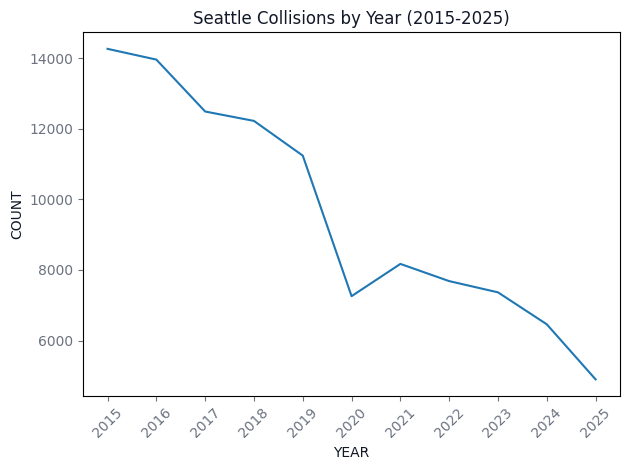

In [11]:
df_count_year = df.groupby('YEAR').count().get(['OBJECTID']).reset_index().rename(columns={'OBJECTID': 'COUNT'})
sns.lineplot(data=df_count_year, x='YEAR', y='COUNT')
plt.title('Seattle Collisions by Year (2015-2025)')
plt.xticks(np.arange(2015, 2026, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Day_of_Week'] = df['INCDATE'].dt.day_name()

avg_by_day = df.groupby('Day_of_Week').size() / df['Day_of_Week'].nunique()
avg_by_day

Day_of_Week
Friday       2467.000000
Monday       2030.714286
Saturday     2076.428571
Sunday       1742.142857
Thursday     2367.857143
Tuesday      2215.000000
Wednesday    2242.285714
dtype: float64

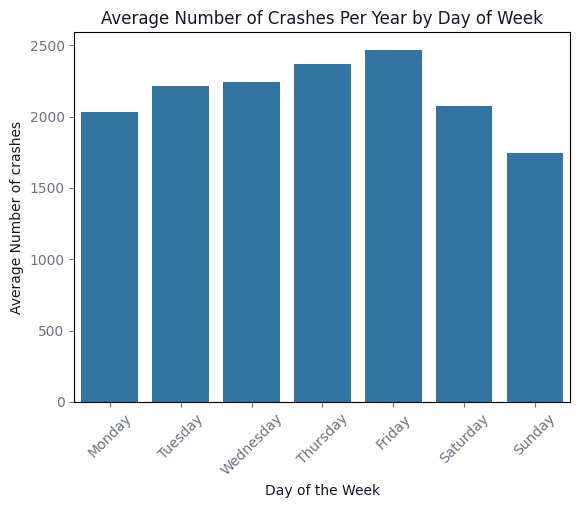

In [13]:
sns.barplot(x=avg_by_day.index, y=avg_by_day.values, order=day_order)
plt.title('Average Number of Crashes Per Year by Day of Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Number of crashes')
plt.xticks(rotation=45)
plt.show()

In [14]:
def get_season(month):
    if ((month > 0) & (month < 3)) | (month == 12):
        return 'Winter'
    elif (month > 2) & (month < 6):
        return 'Spring'
    elif (month > 5) & (month < 9):
        return 'Summer'
    elif (month > 8) & (month < 12):
        return 'Fall'

df = df.assign(Season=df.get('INCDATE').dt.month.apply(get_season))
df

,OBJECTID,SE_ANNO_CAD_DATA,INCKEY,COLDETKEY,REPORTNO,STATUS,ADDRTYPE,INTKEY,LOCATION,SEVERITYCODE,...,CROSSWALKKEY,HITPARKEDCAR,SOURCE,SOURCEDESC,ADDDTTM,MODDTTM,geometry,YEAR,Day_of_Week,Season
0,86862579,,205600,205760,3737771,Matched,Block,NaN,E PIKE ST BETWEEN BROADWAY AND 10TH AVE,1,...,0,Y,PTCR,Police Traffic Collision Report,"Wed, 28 Oct 2015 00:00:00 GMT","Mon, 07 Dec 2015 00:00:00 GMT",POINT (-122.32011 47.61408),2015,Wednesday,Fall
1,86862580,,316000,317500,3814591,Unmatched,Block,NaN,BOYLSTON AVE E BETWEEN E HARRISON ST AND E REP...,0,...,0,N,PTCR,Police Traffic Collision Report,"Wed, 13 Mar 2019 00:00:00 GMT",None,POINT (-122.32307 47.62257),2019,Friday,Spring
2,86862581,,202800,202940,3737876,Matched,Block,NaN,E YESLER WAY BETWEEN 22ND AVE AND 23RD AVE,2,...,0,N,PTCR,Police Traffic Collision Report,"Wed, 23 Sep 2015 00:00:00 GMT","Fri, 02 Oct 2015 00:00:00 GMT",POINT (-122.30304 47.60167),2015,Saturday,Fall
5,86862584,,254800,255440,3784720,Matched,Block,NaN,AIRPORT WAY S BETWEEN S CARSTENS PL AND S HOME...,1,...,0,N,PTCR,Police Traffic Collision Report,"Mon, 20 Nov 2017 00:00:00 GMT","Wed, 03 Jan 2018 00:00:00 GMT",POINT (-122.31867 47.55102),2017,Saturday,Fall
7,86862586,,229900,230280,3771776,Matched,Intersection,29756.0,HARVARD AVE AND SENECA ST,2,...,523244,N,PTCR,Police Traffic Collision Report,"Wed, 16 Nov 2016 00:00:00 GMT","Thu, 10 May 2018 00:00:00 GMT",POINT (-122.32209 47.61274),2016,Thursday,Fall
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258857,87121436,,387175,388715,EG29690,Unmatched,Block,NaN,S MICHIGAN ST BETWEEN 5TH PL S AND 6TH AVE S,1,...,0,N,PTCR,Police Traffic Collision Report,"Tue, 06 Jan 2026 00:00:00 GMT","Tue, 06 Jan 2026 00:00:00 GMT",POINT (-122.32671 47.5461),2025,Thursday,Fall
258858,87121437,,387265,388805,3889411,Unmatched,Block,NaN,NW MARKET ST BETWEEN 14TH AVE NW AND 15TH AVE NW,2,...,0,N,PTCR,Police Traffic Collision Report,"Wed, 07 Jan 2026 00:00:00 GMT","Wed, 07 Jan 2026 00:00:00 GMT",POINT (-122.3749 47.66867),2025,Monday,Winter
258859,87121438,,385905,387445,3924709,Matched,Intersection,30352.0,COLUMBIA ST AND WESTERN AVE,2,...,0,N,PTCR,Police Traffic Collision Report,"Wed, 12 Nov 2025 00:00:00 GMT","Thu, 20 Nov 2025 00:00:00 GMT",POINT (-122.33604 47.6028),2025,Saturday,Summer
258860,87121439,,386852,388392,3936951,Matched,Intersection,36601.0,LAKE CITY WAY NE AND NE 125TH ST,1,...,0,N,PTCR,Police Traffic Collision Report,"Wed, 17 Dec 2025 00:00:00 GMT","Mon, 05 Jan 2026 00:00:00 GMT",POINT (-122.29523 47.71928),2025,Sunday,Summer


In [15]:
df_by_seasons = df.groupby('Season').size()
df_by_seasons

Season
Fall      26940
Spring    26069
Summer    27291
Winter    25690
dtype: int64

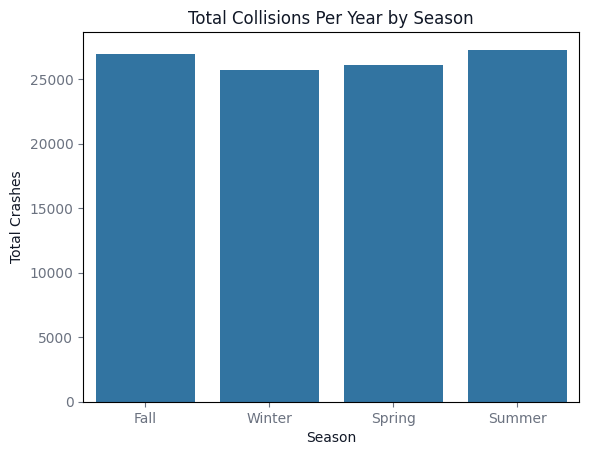

In [16]:
sns.barplot(x= df_by_seasons.index, y=df_by_seasons.values, order=['Fall', 'Winter', 'Spring', 'Summer'])
plt.title('Total Collisions Per Year by Season')
plt.xlabel('Season')
plt.ylabel('Total Crashes')
plt.show()

In [17]:
df_by_season_2024 = df[df.get('INCDATE').dt.year == 2024].groupby('Season').size()
df_by_season_2024

Season
Fall      1563
Spring    1659
Summer    1656
Winter    1582
dtype: int64

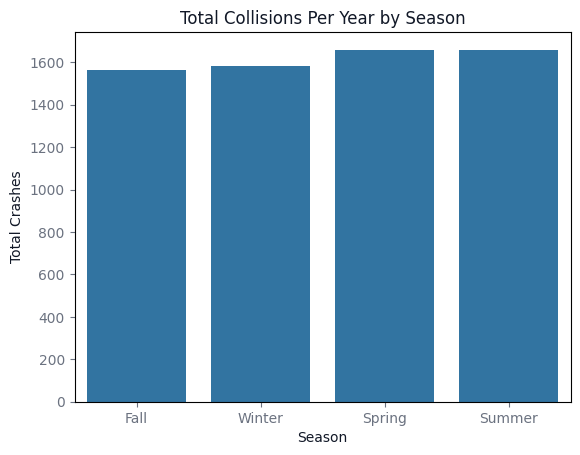

In [18]:
sns.barplot(x= df_by_season_2024.index, y=df_by_season_2024.values, order=['Fall', 'Winter', 'Spring', 'Summer'])
plt.title('Total Collisions Per Year by Season')
plt.xlabel('Season')
plt.ylabel('Total Crashes')
plt.show()

### Analyzing vehicle dataset

In [19]:
df_vehicle = pd.read_csv('data/SDOT_Vehicle.csv')
df_vehicle

/var/folders/kg/syn5dsfn40l0n2qfhr_8whqh0000gn/T/ipykernel_21129/3550853642.py:1: DtypeWarning: Columns (10,12,14,16,23,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df_vehicle = pd.read_csv('data/SDOT_Vehicle.csv')


,OBJECTID,COLLISIONVEHDETKEY,COLDETKEY,Added date,ST_PARTCPNT_TYPE_CODE,ST_PARTCPNT_TYPE_DESC,ST_POSTEDSPD,ST_RDSURF_CODE,ST_RDSURF_DESC,ST_SEQ_EVNTS1,...,Source of the collision report,Source description,Incident Date,Incident Date Time,Report Number,Added by User,Modified by,Modified date,x,y
0,3429527,71831,45400,4/18/2013 12:00:00 AM,3.0,Vehicle,NaN,NaN,NaN,1.0,...,PTCR,Police Traffic Collision Report,4/25/2005 12:00:00 AM,4/25/2005 6:00:00 AM,1791522,Conversion,NaN,NaN,1.274168e+06,218175.832803
1,3429528,492238,1271,12/19/2014 12:00:00 AM,3.0,Vehicle,30.0,2.0,Blacktop,1.0,...,PTCR,Police Traffic Collision Report,4/1/2013 12:00:00 AM,4/1/2013 5:30:00 PM,3380914,STATE INTERFACE,NaN,NaN,1.259551e+06,210455.386629
2,3429529,492239,1271,12/19/2014 12:00:00 AM,3.0,Vehicle,30.0,2.0,Blacktop,1.0,...,PTCR,Police Traffic Collision Report,4/1/2013 12:00:00 AM,4/1/2013 5:30:00 PM,3380914,STATE INTERFACE,NaN,NaN,1.259551e+06,210455.386629
3,3429530,492052,1395,12/19/2014 12:00:00 AM,3.0,Vehicle,30.0,1.0,Concrete,1.0,...,PTCR,Police Traffic Collision Report,4/3/2013 12:00:00 AM,4/3/2013 9:29:00 PM,3467091,STATE INTERFACE,NaN,NaN,1.265607e+06,255946.241842
4,3429531,492053,1395,12/19/2014 12:00:00 AM,3.0,Vehicle,30.0,1.0,Concrete,1.0,...,PTCR,Police Traffic Collision Report,4/3/2013 12:00:00 AM,4/3/2013 9:29:00 PM,3467091,STATE INTERFACE,NaN,NaN,1.265607e+06,255946.241842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
428897,3858424,875447,374157,10/3/2024 12:00:00 AM,3.0,Vehicle,25.0,1.0,Concrete,NaN,...,PTCR,Police Traffic Collision Report,6/18/2024 12:00:00 AM,6/18/2024 12:08:00 AM,3908229,STATE INTERFACE,NaN,NaN,1.266108e+06,198213.895036
428898,3858425,875339,374492,10/3/2024 12:00:00 AM,3.0,Vehicle,NaN,1.0,Concrete,NaN,...,PTCR,Police Traffic Collision Report,6/28/2024 12:00:00 AM,6/28/2024 2:17:00 AM,3932033,STATE INTERFACE,NaN,NaN,1.268657e+06,211444.498168
428899,3858426,875340,374492,10/3/2024 12:00:00 AM,3.0,Vehicle,NaN,1.0,Concrete,NaN,...,PTCR,Police Traffic Collision Report,6/28/2024 12:00:00 AM,6/28/2024 2:17:00 AM,3932033,STATE INTERFACE,NaN,NaN,1.268657e+06,211444.498168
428900,3858427,872937,372595,8/5/2024 12:00:00 AM,3.0,Vehicle,25.0,1.0,Concrete,NaN,...,PTCR,Police Traffic Collision Report,3/18/2024 12:00:00 AM,3/18/2024 4:08:00 PM,3837799,STATE INTERFACE,NaN,NaN,1.271136e+06,210589.061231


In [20]:
df_vehicle_type = df_vehicle.groupby('ST_VEH_TYPE_DESC').size()
df_vehicle_type

ST_VEH_TYPE_DESC
Bus or Motor Stage                                    4669
Farm Tractor and/or Farm Equipment                       1
Moped                                                  213
Motorcycle                                            4211
Not Stated                                           32007
Other                                                 1146
Passenger Car                                       231733
Pickup, Panel Truck or Vannette Under 10,000 lbs    137636
Railway Vehicle                                        170
School Bus                                             661
Scooter Bike                                           712
Taxi                                                  2187
Truck (Flatbed, Van, etc)                             8169
Truck - Double trailer Combinations                    104
Truck Tractor                                          565
Truck Tractor and Semi-Trailer                        3446
Truck and Trailer                      

In [21]:
# Combining vehicle type into broader categories
passenger_vehicle = ['Passenger Car', 'Taxi']
truck_suv = ['Pickup, Panel Truck or Vannette Under 10,000 lbs']
two_wheeled_vehicle = ['Motorcycle', 'Moped', 'Scooter Bike']
commercial_trucks = ['Truck (Flatbed, Van, etc)', 'Truck - Double trailer Combinations', 'Truck Tractor', 'Truck Tractor and Semi-Trailer', 'Truck and Trailer']
buses = ['Bus or Motor Stage', 'School Bus']

df_vehicle['ST_VEH_TYPE_DESC'] = df_vehicle['ST_VEH_TYPE_DESC'].replace(passenger_vehicle, 'Passenger Vehicle')
df_vehicle['ST_VEH_TYPE_DESC'] = df_vehicle['ST_VEH_TYPE_DESC'].replace(truck_suv, 'Truck/SUV')
df_vehicle['ST_VEH_TYPE_DESC'] = df_vehicle['ST_VEH_TYPE_DESC'].replace(two_wheeled_vehicle, 'Two-Wheeled')
df_vehicle['ST_VEH_TYPE_DESC'] = df_vehicle['ST_VEH_TYPE_DESC'].replace(commercial_trucks, 'Commercial Trucks')
df_vehicle['ST_VEH_TYPE_DESC'] = df_vehicle['ST_VEH_TYPE_DESC'].replace(buses, 'Buses')

df_vehicle.groupby('ST_VEH_TYPE_DESC').size()

ST_VEH_TYPE_DESC
Buses                                   5330
Commercial Trucks                      13479
Farm Tractor and/or Farm Equipment         1
Not Stated                             32007
Other                                   1146
Passenger Vehicle                     233920
Railway Vehicle                          170
Truck/SUV                             137636
Two-Wheeled                             5136
dtype: int64

### Merging datasets to utilize injuries and vehicle columns

In [22]:
df_merged = pd.merge(df, df_vehicle[['COLDETKEY', 'ST_VEH_TYPE_DESC']], on='COLDETKEY', how='left')
df_merged

,OBJECTID,SE_ANNO_CAD_DATA,INCKEY,COLDETKEY,REPORTNO,STATUS,ADDRTYPE,INTKEY,LOCATION,SEVERITYCODE,...,HITPARKEDCAR,SOURCE,SOURCEDESC,ADDDTTM,MODDTTM,geometry,YEAR,Day_of_Week,Season,ST_VEH_TYPE_DESC
0,86862579,,205600,205760,3737771,Matched,Block,NaN,E PIKE ST BETWEEN BROADWAY AND 10TH AVE,1,...,Y,PTCR,Police Traffic Collision Report,"Wed, 28 Oct 2015 00:00:00 GMT","Mon, 07 Dec 2015 00:00:00 GMT",POINT (-122.32011 47.61408),2015,Wednesday,Fall,Passenger Vehicle
1,86862579,,205600,205760,3737771,Matched,Block,NaN,E PIKE ST BETWEEN BROADWAY AND 10TH AVE,1,...,Y,PTCR,Police Traffic Collision Report,"Wed, 28 Oct 2015 00:00:00 GMT","Mon, 07 Dec 2015 00:00:00 GMT",POINT (-122.32011 47.61408),2015,Wednesday,Fall,Truck/SUV
2,86862580,,316000,317500,3814591,Unmatched,Block,NaN,BOYLSTON AVE E BETWEEN E HARRISON ST AND E REP...,0,...,N,PTCR,Police Traffic Collision Report,"Wed, 13 Mar 2019 00:00:00 GMT",None,POINT (-122.32307 47.62257),2019,Friday,Spring,NaN
3,86862581,,202800,202940,3737876,Matched,Block,NaN,E YESLER WAY BETWEEN 22ND AVE AND 23RD AVE,2,...,N,PTCR,Police Traffic Collision Report,"Wed, 23 Sep 2015 00:00:00 GMT","Fri, 02 Oct 2015 00:00:00 GMT",POINT (-122.30304 47.60167),2015,Saturday,Fall,Passenger Vehicle
4,86862581,,202800,202940,3737876,Matched,Block,NaN,E YESLER WAY BETWEEN 22ND AVE AND 23RD AVE,2,...,N,PTCR,Police Traffic Collision Report,"Wed, 23 Sep 2015 00:00:00 GMT","Fri, 02 Oct 2015 00:00:00 GMT",POINT (-122.30304 47.60167),2015,Saturday,Fall,Passenger Vehicle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183818,87121437,,387265,388805,3889411,Unmatched,Block,NaN,NW MARKET ST BETWEEN 14TH AVE NW AND 15TH AVE NW,2,...,N,PTCR,Police Traffic Collision Report,"Wed, 07 Jan 2026 00:00:00 GMT","Wed, 07 Jan 2026 00:00:00 GMT",POINT (-122.3749 47.66867),2025,Monday,Winter,NaN
183819,87121438,,385905,387445,3924709,Matched,Intersection,30352.0,COLUMBIA ST AND WESTERN AVE,2,...,N,PTCR,Police Traffic Collision Report,"Wed, 12 Nov 2025 00:00:00 GMT","Thu, 20 Nov 2025 00:00:00 GMT",POINT (-122.33604 47.6028),2025,Saturday,Summer,Truck/SUV
183820,87121439,,386852,388392,3936951,Matched,Intersection,36601.0,LAKE CITY WAY NE AND NE 125TH ST,1,...,N,PTCR,Police Traffic Collision Report,"Wed, 17 Dec 2025 00:00:00 GMT","Mon, 05 Jan 2026 00:00:00 GMT",POINT (-122.29523 47.71928),2025,Sunday,Summer,Passenger Vehicle
183821,87121440,,386506,388046,EG23297,Matched,Block,NaN,E CHERRY ST BETWEEN 15TH AVE AND 16TH AVE,2,...,Y,PTCR,Police Traffic Collision Report,"Mon, 08 Dec 2025 00:00:00 GMT","Tue, 09 Dec 2025 00:00:00 GMT",POINT (-122.3122 47.60804),2025,Sunday,Summer,Passenger Vehicle


In [23]:
# Combining injury severity
top_vehicle_injuries = df_merged.groupby('ST_VEH_TYPE_DESC')['INJURIES'].sum().sort_values(ascending=False)
print(f'{top_vehicle_injuries} + \n')

top_vehicle_serious_injuries = df_merged.groupby('ST_VEH_TYPE_DESC')['SERIOUSINJURIES'].sum().sort_values(ascending=False)
print(f'{top_vehicle_serious_injuries} + \n')

top_vehicle_fatalities = df_merged.groupby('ST_VEH_TYPE_DESC')['FATALITIES'].sum().sort_values(ascending=False)
print(f'{top_vehicle_fatalities} + \n')

ST_VEH_TYPE_DESC
Passenger Vehicle    38351
Truck/SUV            27216
Two-Wheeled           1509
Not Stated            1254
Commercial Trucks     1250
Buses                 1030
Other                  186
Railway Vehicle         32
Name: INJURIES, dtype: int32 + 

ST_VEH_TYPE_DESC
Passenger Vehicle    1524
Truck/SUV            1310
Two-Wheeled           303
Buses                 112
Not Stated             94
Commercial Trucks      75
Other                  49
Railway Vehicle         4
Name: SERIOUSINJURIES, dtype: int32 + 

ST_VEH_TYPE_DESC
Truck/SUV            153
Passenger Vehicle    132
Two-Wheeled           38
Commercial Trucks     18
Buses                 17
Not Stated            13
Other                  9
Railway Vehicle        1
Name: FATALITIES, dtype: int32 + 



In [24]:
combined_data = pd.DataFrame({'Injuries': top_vehicle_injuries, 
                              'Serious_Injuries': top_vehicle_serious_injuries,
                              'Deaths': top_vehicle_fatalities})
combined_data

,Injuries,Serious_Injuries,Deaths
ST_VEH_TYPE_DESC,,,
Buses,1030,112,17
Commercial Trucks,1250,75,18
Not Stated,1254,94,13
Other,186,49,9
Passenger Vehicle,38351,1524,132
Railway Vehicle,32,4,1
Truck/SUV,27216,1310,153
Two-Wheeled,1509,303,38


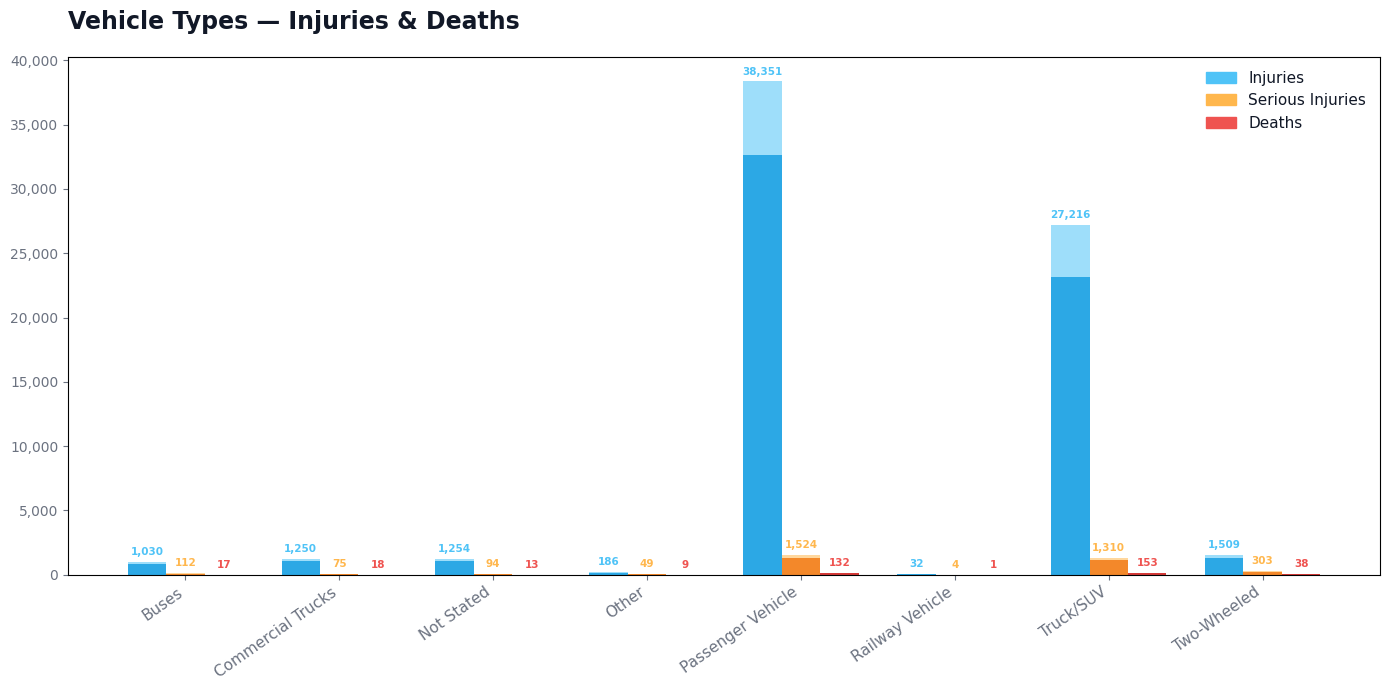

In [25]:

bar_width = 0.25
indices   = np.arange(len(combined_data))

fig, ax = plt.subplots(figsize=(14, 7))
fig.subplots_adjust(top=0.85)

colors = {
    'Injuries':         ('#4fc3f7', '#0288d1'),
    'Serious_Injuries': ('#ffb74d', '#e65100'), 
    'Deaths':           ('#ef5350', '#b71c1c'), 
}

def gradient_bar(ax, x, height, width, top_color, bot_color, **kwargs):
    """Draw a bar with a simple top-highlight effect using two rectangles."""
    ax.bar(x, height * 0.85, width, color=bot_color, **kwargs)
    ax.bar(x, height,        width, color=top_color, alpha=0.55, **kwargs)

for i, (col, (tc, bc)) in enumerate(colors.items()):
    offset = (i - 1) * bar_width
    label  = col.replace('_', ' ')
    gradient_bar(ax, indices + offset, combined_data[col], bar_width, tc, bc, label=label)

for i, (col, (tc, _)) in enumerate(colors.items()):
    offset = (i - 1) * bar_width
    for x, val in zip(indices + offset, combined_data[col]):
        if val > 0:
            ax.text(x, val + combined_data.values.max() * 0.01,
                    f'{val:,}', ha='center', va='bottom',
                    fontsize=7.5, color=tc, fontweight='bold')

ax.set_xticks(indices)
ax.set_xticklabels(combined_data.index, rotation=35, ha='right', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))

ax.set_title('Vehicle Types — Injuries & Deaths',
             fontsize=17, fontweight='bold', color='#111827', pad=20, loc='left')

patches = [mpatches.Patch(color=tc, label=col.replace('_', ' '))
           for col, (tc, _) in colors.items()]

ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(1, 1),
          frameon=False, labelcolor='#111827', fontsize=11)

fig.subplots_adjust(top=0.82)  

plt.tight_layout()
plt.show()

### Spatial Data Analysis

In [26]:
# Checking for consistency of year.
df['INCDATE'] = pd.to_datetime(df['INCDATE'])
df['YEAR'] = df.get('INCDATE').dt.year
df.groupby('YEAR').size()

YEAR
2015    14259
2016    13955
2017    12485
2018    12219
2019    11236
2020     7257
2021     8170
2022     7683
2023     7365
2024     6460
2025     4901
dtype: int64

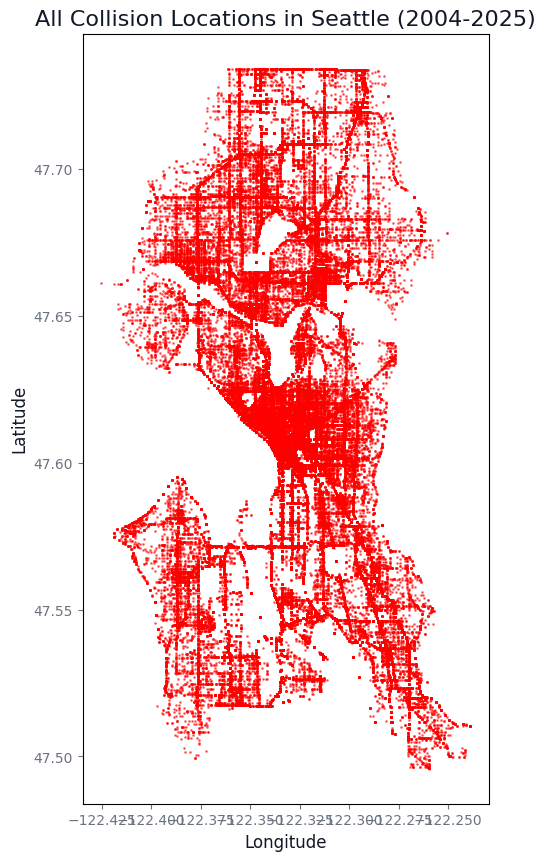

In [27]:
# Basic plot of all collision points
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
df.plot(ax=ax, color='red', markersize=1, alpha=0.5)
ax.set_title('All Collision Locations in Seattle (2004-2025)', fontsize=16)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
plt.show()

In [28]:
# Check the coordinate reference system (CRS)
print("CRS:", df.crs)
print(df.describe())

CRS: EPSG:4326
           OBJECTID         INCKEY      COLDETKEY         INTKEY  \
count  1.059900e+05  105990.000000  105990.000000   37607.000000   
mean   8.706654e+07  293958.986621  294957.264053   41654.332279   
min    8.686258e+07   16416.000000   16416.000000   23807.000000   
25%    8.704190e+07  233402.250000  233802.250000   28792.000000   
50%    8.706841e+07  311638.500000  312998.500000   30436.000000   
75%    8.709491e+07  348000.750000  349500.750000   34387.000000   
max    8.712144e+07  387933.000000  389473.000000  858453.000000   
std    3.748461e+04   62650.903374   63193.730290   67466.193195   

         PERSONCOUNT       PEDCOUNT    PEDCYLCOUNT       VEHCOUNT  \
count  105990.000000  105990.000000  105990.000000  105990.000000   
mean        2.130503       0.046118       0.033088       1.575837   
min         0.000000       0.000000       0.000000       0.000000   
25%         2.000000       0.000000       0.000000       1.000000   
50%         2.000000       

/Users/trentonpham/Code/seattle_collision/.venv/lib/python3.10/site-packages/mapclassify/classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


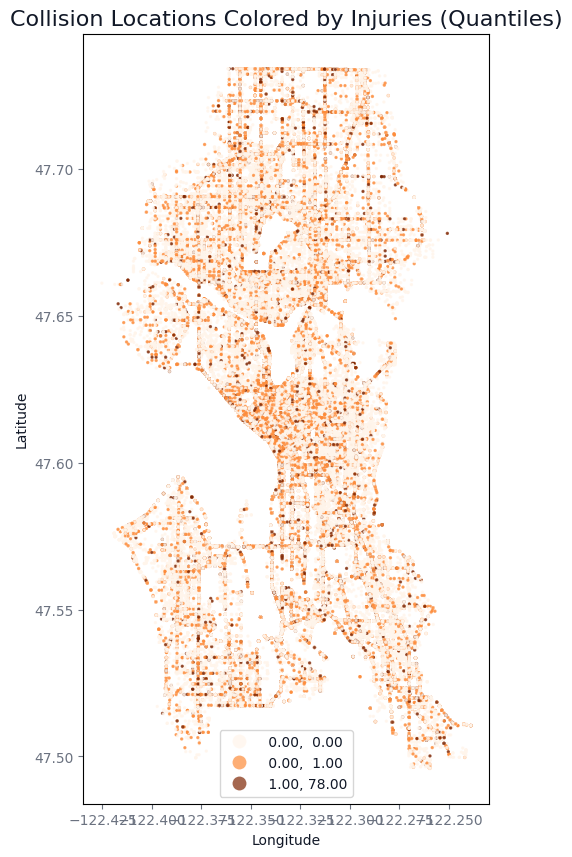

/Users/trentonpham/Code/seattle_collision/.venv/lib/python3.10/site-packages/mapclassify/classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 2.
  self.bins = quantile(y, k=k)


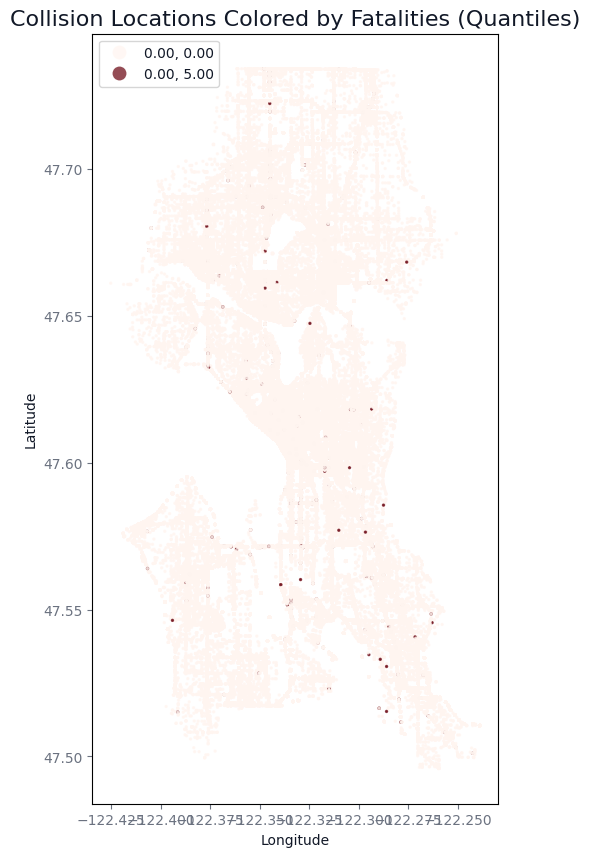

In [30]:
# Plot collisions colored by number of injuries
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
df.plot(column='INJURIES', ax=ax, legend=True, markersize=2, alpha=0.7, cmap='Oranges', scheme='quantiles')
ax.set_title('Collision Locations Colored by Injuries (Quantiles)', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

# Plot collisions colored by number of fatalities
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
df.plot(column='FATALITIES', ax=ax, legend=True, markersize=2, alpha=0.7, cmap='Reds', scheme='quantiles')
ax.set_title('Collision Locations Colored by Fatalities (Quantiles)', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

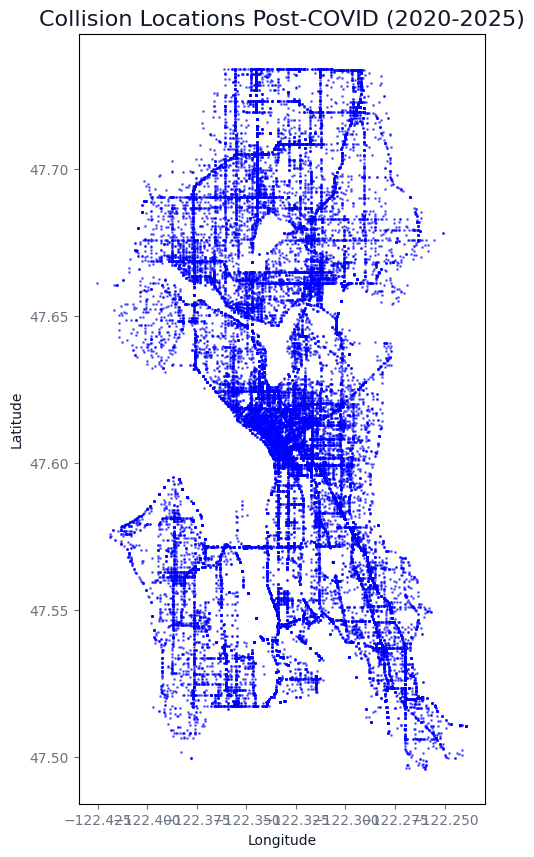

In [31]:
# Filter for recent years (2020-2025)
gdf_recent = df[df['INCDATE'].dt.year >= 2020]

# Plot recent collisions
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
gdf_recent.plot(ax=ax, color='blue', markersize=1, alpha=0.5)
ax.set_title('Collision Locations Post-COVID (2020-2025)', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

/Users/trentonpham/Code/seattle_collision/.venv/lib/python3.10/site-packages/mapclassify/classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


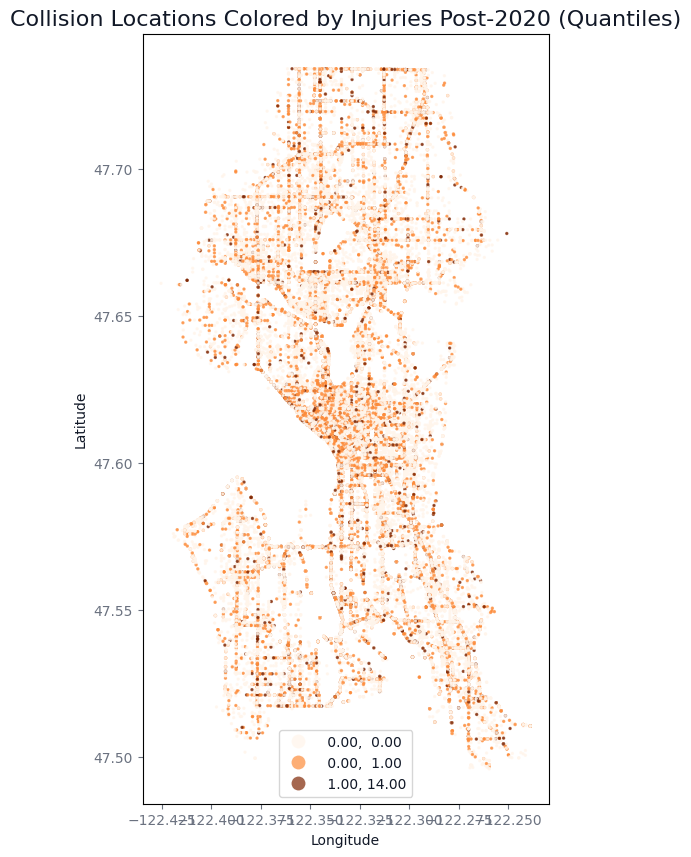

/Users/trentonpham/Code/seattle_collision/.venv/lib/python3.10/site-packages/mapclassify/classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 2.
  self.bins = quantile(y, k=k)


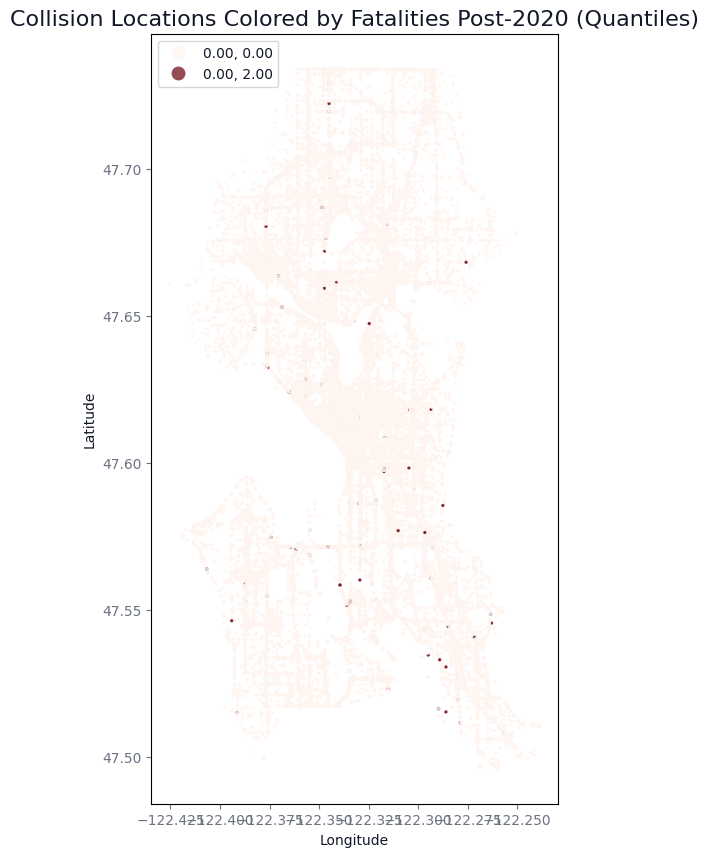

In [32]:
# Plot collisions colored by number of injuries
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
gdf_recent.plot(column='INJURIES', ax=ax, legend=True, markersize=2, alpha=0.7, cmap='Oranges', scheme='quantiles')
ax.set_title('Collision Locations Colored by Injuries Post-2020 (Quantiles)', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

# Plot collisions colored by number of fatalities
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
gdf_recent.plot(column='FATALITIES', ax=ax, legend=True, markersize=2, alpha=0.7, cmap='Reds', scheme='quantiles')
ax.set_title('Collision Locations Colored by Fatalities Post-2020 (Quantiles)', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()